#### PROMPTS

In [1]:
# - If the user wants to begin an interview for a job application, begin an interview by calling StartInterview
# - If the user has finished an interview, update the job application by calling UpdateMemory tool with type `application`

In [2]:
# System Message
MODEL_SYSTEM_MESSAGE = """You are a helpful chatbot. 

You are designed to be a companion to a user, helping them build a profile of their professional and academic career in order to attend job interviews in the user's stead.

You have a long term memory which keeps track of four things:
1. The user's AnnotatedResume (high level information about the user's professional and academic career with annotations for each item)
2. A list of the user's job applications
3. The user's documents which contain fine-grain information about the user's professional and academic career like project reports, specific work experiences, etc.
4. General instructions for updating the user profile.

Here is the current AnnotatedResume (may be empty if no information has been collected yet):
<annotated_resume>
{annotated_resume}
</annotated_resume>

Here is the current list of job applications (may be empty if no applications have been started yet):
<job_applications>
{job_applications}
</job_applications>

Here is the current list of documents (may be empty if no documents have been uploaded yet):
<documents>
{documents}
</documents>

Here are the current user-specified preferences for updating the user resume (may be empty if no preferences have been specified yet):
<instructions>
{instructions}
</instructions>

Here are your instructions for reasoning about the user's messages:

1. Reason carefully about the user's messages as presented below. 

2. Decide whether any of the your long-term memory should be updated:
- If professional or academic information was provided about the user, update the user's resume by calling UpdateMemory tool with type `annotated_resume` if the information is high level, or `document` if the information is fine-grain
- If the user has specified a job application, update the job applications by calling UpdateMemory tool with type `application`
- If the user has specified preferences for how to update their resume, update the instructions by calling UpdateMemory tool with type `instructions`

3. If the user wants to begin an interview for a job application, set the active application and begin an interview by calling UpdateMemory tool with type `active_application`. After the interview is complete, update the job application by calling UpdateMemory tool with type `application`

4. Tell the user that you have updated your memory, if appropriate:
- Tell the user you have updated the user's annotated resume, documents, and/or job applications
- Do not tell the user that you have updated instructions

5. Err on the side of updating the AnnotatedResume and Documents. No need to ask for explicit permission.

6. Respond naturally to user user after a tool call was made to save memories, or if no tool call was made."""

In [3]:
# Trustcall instruction
TRUSTCALL_INSTRUCTION = """Reflect on following interaction. 

Use the provided tools to retain any necessary memories about the user. 

Use parallel tool calling to handle updates and insertions simultaneously.

System Time: {time}"""

In [4]:
# Instructions for updating the ToDo list
CREATE_INSTRUCTIONS = """Reflect on the following interaction.

Based on this interaction, update your instructions for how to update profile items. 

Use any feedback from the user to update how they like to have items added, etc.

Your current instructions are:

<current_instructions>
{current_instructions}
</current_instructions>"""

#### STATES/SCHEMA

In [5]:
# Imports
from typing import Optional, Literal
from pydantic import BaseModel, Field
from datetime import date

In [6]:
# User profile schema

class Item(BaseModel):
    """ This is a single item in the user's Annotated Resume """
    content : str = Field(
        description="The content of the item",
        default=None
    )
    interview_notes: Optional[str] = Field(
        description="Interview notes relevant to the item",
        default=None
    )

class ItemCollection(BaseModel):
    """ This is a collection of items in the user's annotated resume """
    items: list[Item] = Field(
        description="The items in the collection",
        default_factory=list
    )
    notes: Optional[str] = Field(
        description="Notes relevant to the collection",
        default=None
    )

class AnnotatedResume(BaseModel):
    """This is the annotate resume of the user you are chatting with"""

    # required categories
    contact_info: ItemCollection = Field(
        description="""
            The user's contact information which may include the following and more
            (1) name (do not use nicknames), 
            (2) permanent address (or school/local address), 
            (3) phone number, and 
            (4) email address
            """,
            default=None
    )

    objective: Optional[Item] = Field(
        description="""
            A brief statement of the type of position for which the user wishes to be considered. 

            May be stated 
            (1) by job title, 
            (2) by level or type, 
            (3) in terms of the skills the user wishes to use or develop, or 
            (4) as a combination of all three.
            """,
        default=None
    )

    education: ItemCollection = Field(
        description="""
            The user's education history which may include the following and more
            (1) begin with most recent degree (omit high school if college degree has been earned),
            (2) other degrees received or anticipated, major (concentration), minor, and certificate program
            (3) date the degree was granted or expected
            (4) university name and location
            (5) GPA (if 3.0 or higher)
            (6) academic honors, scholarships, and awards
            (7) may include a section that involves relevant coursework
            (8) study abroad experiences (if any)
            """,
        default=None
    )

    technical_skills: ItemCollection = Field(
        description="Technical skills that the user has",
        default=None
    )

    experience: Optional[ItemCollection] = Field(
        description="""
            Work experience that the user has 
            (1) list job/positon title
            (2) organization/company name
            (3) location (city, state)
            (4) dates

            ALWAYS start with action verbs, such as "collaborated," "developed," "managed," "created," etc. to describe job tasks, activities, and accomplishments.
            
            Provide specific examples of accomplishments using statistics and numbers.

            Include paid paid experiences such as full-time, part-time, internships, summer jobs, assistantships, etc.

            Include unpaid internships, extended research, projects, and extracurricular activities, coursework, or class projects that often lead to valuable knowledge and skills.
            """,
        default=None
    )

    activities: Optional[ItemCollection] = Field(
        description="""
            Activities that the user has participated in or out of school, if not already covered under experiences. Include activities where the user has developed significant transferable skills, such as leadership and teamwork.
            """,
        default=None
    )

    skills: ItemCollection = Field(
        description="""
            Skills that the user has which may include
            (1) computer skills (hardware, software, programming languages, etc.)
            (2) foreign language proficiency (literate, fluent)
            """,
        default=None
    )

    non_academic_honors_and_awards: Optional[ItemCollection] = Field(
        description="Any non-academic awards and honors that the user has received",
        default=None
    )

    professional_affiliations: Optional[ItemCollection] = Field(
        description="Professional affiliations that the user has",
        default=None
    )

    other: Optional[ItemCollection] = Field(
        description="Any other pertinent information about the user such as citizenship, special licenses, certificates, clearances",
        default=None
    )

    references: Optional[ItemCollection] = Field(
        description="References that the user has",
        default=None
    )

In [7]:
# Job Posting schema

class Company(BaseModel):
    """ Employer details """
    name: Optional[str] = Field(description="The name of the company.", default=None)
    location: Optional[str] = Field(description="The primary location of the company or job.", default=None)
    industry: Optional[str] = Field(description="The industry in which the company operates.", default=None)

class SalaryRange(BaseModel):
    """ Salary range offered """
    min: Optional[float] = Field(description="Minimum salary offered.", default=None)
    max: Optional[float] = Field(description="Maximum salary offered.", default=None)
    currency: Optional[str] = Field(
        description="Currency in which the salary is paid (e.g., USD, EUR).", default=None
    )

class RequiredExperience(BaseModel):
    """ Experience requirements for the job """
    years: Optional[int] = Field(description="Number of years of experience required.", default=None)
    field: Optional[str] = Field(description="Relevant field of experience.", default=None)

class EmploymentType(BaseModel):
    """ Type of employment offered """
    type: Literal["Full-time", "Part-time", "Contract", "Temporary", "Internship"] = Field(
        description="Type of employment offered.",
        default=None
    )

class JobLocationType(BaseModel):
    """ Type of job location """
    type: Literal["Remote", "On-site", "Hybrid"] = Field(
        description="Type of job location.",
        default=None
    )

class JobPosting(BaseModel):
    """ Job Posting details including job title, company, location, and job description. """

    job_title: Optional[str] = Field(description="The title of the job position.", default=None)
    company: Optional[Company] = Field(
        description="Company details including name and location.", 
        default=None
    )
    employment_type: Optional[EmploymentType] = Field(
        description="Type of employment offered.",
        default=None
    )
    job_description: Optional[str] = Field(
        description="A detailed description of the job responsibilities and expectations.", default=None
    )
    qualifications: Optional[list[str]] = Field(
        description="List of required qualifications and skills.", default=None
    )
    responsibilities: Optional[list[str]] = Field(
        description="Key responsibilities associated with the job.", default=None
    )
    salary_range: Optional[SalaryRange] = Field(
        description="Salary range offered for the position.", default=None
    )
    benefits: Optional[list[str]] = Field(
        description="List of benefits offered with the job.", default=None
    )
    required_experience: Optional[RequiredExperience] = Field(
        description="Experience requirements for the job.", default=None
    )
    job_location_type: Optional[str] = Field(
        description="Indicates whether the job is remote, on-site, or hybrid.", default=None
    )
    application_deadline: Optional[date] = Field(
        description="Deadline for submitting applications.", default=None
    )
    contact_email: Optional[str] = Field(
        description="Contact email for application submission.", default=None
    )
    posting_date: Optional[date] = Field(
        description="Date when the job was posted.", default=None
    )

In [8]:
# Job Application schema

class Application(BaseModel):
    """ This is an instance of a job application """
    posting: JobPosting = Field(
        description="The job posting to which the user is applying",
        default=None
    )
    status: Literal["In Progress", "Submitted", "Rejected", "Interview Scheduled", "Offer Extended", "Offer Accepted", "Offer Declined"] = Field(
        description="The status of the job application",
        default="In Progress"
    )
    interview_notes: Optional[str] = Field(
        description="Notes from the interview process",
        default=None
    )

# FIXME: removing a job application leaves an empty list
class JobApplications(BaseModel):
    """This is the set of job applications that the user is working on or has completed"""
    applications: list[Application] = Field(
        description="List of job applications that the user is working on or has completed",
        default_factory=list
    )

In [9]:
# Documents Schema
class Document(BaseModel):
    """ This is a user document with content and source """
    title: str
    content: str
    source: str

class DocumentCollection(BaseModel):
    """ Collection of user's documents """
    documents: list[Document] = Field(
        description="List of user's documents",
        default_factory=list
    )

In [10]:
# Analyst
class Analyst(BaseModel):
    # affiliation: str = Field(
    #     description="Primary affiliation of the analyst.",
    # )
    name: str = Field(
        description="Name of the analyst."
    )
    role: str = Field(
        description="Role of the analyst in the context of the job posting.",
    )
    description: str = Field(
        description="Description of the analyst focus, concerns, and motives.",
    )
    @property
    def persona(self) -> str:
        return f"Name: {self.name}\nRole: {self.role}\nDescription: {self.description}\n"

class Perspectives(BaseModel):
    analysts: list[Analyst] = Field(
        description="Comprehensive list of analysts with their roles.",
    )

#### TOOLS

In [11]:
# Imports
from typing_extensions import TypedDict

In [12]:
# Update memory tool # NOTE: NOT A TOOL
"""
user: memory about the user (eg. facts, achievements)
instructions: user preferences on KG structure
"""
class UpdateMemory(TypedDict):
    """ Decision on what memory type to update """
    update_type: Literal['annotated_resume', 'instructions', 'application', 'document', 'active_application']

#### GRAPHS

##### Main Agent

Node Definitions

In [13]:
# Imports
from trustcall import create_extractor
from langchain_openai import ChatOpenAI
from langgraph.checkpoint.memory import MemorySaver
from langgraph.graph import StateGraph, MessagesState, END, START
from langgraph.store.base import BaseStore
from langgraph.store.memory import InMemoryStore
from langchain_core.runnables import RunnableConfig
from langchain_core.messages import merge_message_runs, HumanMessage, SystemMessage

from datetime import datetime
import uuid

from IPython.display import Image, display

In [14]:
# Model initialization
model = ChatOpenAI(model="gpt-4o", temperature=0)

In [15]:
# Utils
from trustcall import create_extractor

profile_extractor = create_extractor(
    model,
    tools=[AnnotatedResume],
    tool_choice="AnnotatedResume",
)

# Inspect the tool calls made by Trustcall
class Spy:
    def __init__(self):
        self.called_tools = []

    def __call__(self, run):
        # Collect information about the tool calls made by the extractor.
        q = [run]
        while q:
            r = q.pop()
            if r.child_runs:
                q.extend(r.child_runs)
            if r.run_type == "chat_model":
                self.called_tools.append(
                    r.outputs["generations"][0][0]["message"]["kwargs"]["tool_calls"]
                )

def extract_tool_info(tool_calls, schema_name="Memory"):
    """Extract information from tool calls for both patches and new memories.
    
    Args:
        tool_calls: List of tool calls from the model
        schema_name: Name of the schema tool (e.g., "Memory", "ToDo", "Profile")
    """

    # Initialize list of changes
    changes = []
    
    for call_group in tool_calls:
        for call in call_group:
            if call['name'] == 'PatchDoc':
                args = call.get('args', {})
                patches = args.get('patches', [])
                if patches:
                    changes.append({
                        'type': 'update',
                        'doc_id': args.get('json_doc_id'),
                        'planned_edits': args.get('planned_edits'),
                        'value': patches[0].get('value')
                    })
            elif call['name'] == schema_name:
                changes.append({
                    'type': 'new',
                    'value': call['args']
                })

    # Format results as a single string
    result_parts = []
    for change in changes:
        if change['type'] == 'update':
            result_parts.append(
                f"Document {change['doc_id']} updated:\n"
                f"Plan: {change['planned_edits']}\n"
                f"Added content: {change['value']}"
            )
        else:
            result_parts.append(
                f"New {schema_name} created:\n"
                f"Content: {change['value']}"
            )
    
    return "\n\n".join(result_parts)

In [16]:
# class InterviewFeedback(BaseModel):
#     """ Feedback from last conducted interview """
#     : str = Field(
#         description="Feedback from the user after an interview",
#         default=None
#     )

In [17]:
import operator
from typing import Annotated, List

class ParentState(MessagesState):
  """ Parent state for the system """
  final_report: Optional[str] = None
  active_application: Optional[Application] = None
  annotated_resume: Optional[AnnotatedResume] = None
  applications: Optional[JobApplications] = None
  documents: Optional[DocumentCollection] = None
  max_interviews: int = 3
  human_analyst_feedback: Optional[str] = None
  analysts: Optional[list[Analyst]] = None
  sections: Annotated[List, operator.add] = None
  # interview_feedback: Optional[str] = None

In [18]:
# Agent
def hunter(state: ParentState, config: RunnableConfig, store: BaseStore):

    """Load memories from the store and use them to personalize the chatbot's response."""
    
    # Get the user ID from the config
    user_id = config["configurable"]["user_id"]
    
    namespace = ("active_application", user_id)
    memories = store.search(namespace)
    if memories:
        active_application = memories[0].value
    else:
        active_application = None

    # Retrieve profile memory from the store
    namespace = ("annotated_resume", user_id)
    memories = store.search(namespace)
    if memories:
        resume = memories[0].value
    else:
        resume = None

    # Retrieve custom instructions
    namespace = ("instructions", user_id)
    memories = store.search(namespace)
    if memories:
        instructions = memories[0].value
    else:
        instructions = None

    # Retrieve job applications
    namespace = ("applications", user_id)
    memories = store.search(namespace)
    if memories:
        job_applications = memories[0].value
    else:
        job_applications = None

    # Retrieve documents
    namespace = ("documents", user_id)
    if memories:
        documents = memories[0].value
    else:
        documents = None
    
    system_msg = MODEL_SYSTEM_MESSAGE.format(
        annotated_resume=resume, job_applications=job_applications, 
        documents=documents,  instructions=instructions
    )

    # Respond using memory as well as the chat history
    # TODO: Add more tools and allow parallel tool calls
    response = model.bind_tools(
        [UpdateMemory], parallel_tool_calls=False
    ).invoke([SystemMessage(content=system_msg)]+state["messages"])

    return {"messages": [response]}

In [19]:
# Update profile
def update_resume(state: ParentState, config: RunnableConfig, store: BaseStore):

    """Reflect on the chat history and update the memory collection."""
    
    # Get the user ID from the config
    user_id = config["configurable"]["user_id"]

    # Define the namespace for the memories
    namespace = ("annotated_resume", user_id)

    # Retrieve the most recent memories for context
    existing_items = store.search(namespace)

    # Format the existing memories for the Trustcall extractor
    tool_name = "AnnotatedResume"
    existing_memories = (
        [(existing_item.key, tool_name, existing_item.value)
          for existing_item in existing_items] if existing_items else None
    )

    # Merge the chat history and the instruction
    TRUSTCALL_INSTRUCTION_FORMATTED=TRUSTCALL_INSTRUCTION.format(time=datetime.now().isoformat())
    updated_messages=list(merge_message_runs(messages=[SystemMessage(content=TRUSTCALL_INSTRUCTION_FORMATTED)] + state["messages"][:-1]))

    # Invoke the extractor
    result = profile_extractor.invoke({"messages": updated_messages, 
                                         "existing": existing_memories})

    # Save the memories from Trustcall to the store
    for r, rmeta in zip(result["responses"], result["response_metadata"]):
        store.put(namespace,
                  rmeta.get("json_doc_id", str(uuid.uuid4())),
                  r.model_dump(mode="json"),
            )
    tool_calls = state['messages'][-1].tool_calls
    return {"messages": [{"role": "tool", "content": "updated resume", "tool_call_id":tool_calls[0]['id']}]}

In [20]:
# Update job applications
def update_job_applications(state: MessagesState, config: RunnableConfig, store: BaseStore):

    """Reflect on the chat history and update the memory collection."""
    
    # Get the user ID from the config
    user_id = config["configurable"]["user_id"]

    # Define the namespace for the memories
    namespace = ("applications", user_id)

    # Retrieve the most recent memories for context
    existing_items = store.search(namespace)

    # Format the existing memories for the Trustcall extractor
    tool_name = "JobApplications"
    existing_memories = ([(existing_item.key, tool_name, existing_item.value)
                          for existing_item in existing_items]
                          if existing_items
                          else None
                        )

    # Merge the chat history and the instruction
    TRUSTCALL_INSTRUCTION_FORMATTED=TRUSTCALL_INSTRUCTION.format(time=datetime.now().isoformat())
    updated_messages=list(merge_message_runs(messages=[SystemMessage(content=TRUSTCALL_INSTRUCTION_FORMATTED)] + state["messages"][:-1]))

    # Initialize the spy for visibility into the tool calls made by Trustcall
    spy = Spy()
    
    # Create the Trustcall extractor for updating the JobApplications list 
    todo_extractor = create_extractor(
    model,
    tools=[JobApplications],
    tool_choice=tool_name,
    enable_inserts=True
    ).with_listeners(on_end=spy)

    # Invoke the extractor
    result = todo_extractor.invoke({"messages": updated_messages, 
                                    "existing": existing_memories})

    # Save the memories from Trustcall to the store
    for r, rmeta in zip(result["responses"], result["response_metadata"]):
        store.put(namespace,
                  rmeta.get("json_doc_id", str(uuid.uuid4())),
                  r.model_dump(mode="json"),
            )
        
    # Respond to the tool call made in agent, confirming the update
    tool_calls = state['messages'][-1].tool_calls

    # Extract the changes made by Trustcall and add the the ToolMessage returned to agent
    application_update_msg = extract_tool_info(spy.called_tools, tool_name)
    return {"messages": [{"role": "tool", "content": application_update_msg, "tool_call_id":tool_calls[0]['id']}]}

In [21]:
# Update instructions
def update_instructions(state: ParentState, config: RunnableConfig, store: BaseStore):

    """Reflect on the chat history and update the memory collection."""
    
    # Get the user ID from the config
    user_id = config["configurable"]["user_id"]
    
    namespace = ("instructions", user_id)

    existing_memory = store.get(namespace, "user_instructions")
        
    # Format the memory in the system prompt
    system_msg = CREATE_INSTRUCTIONS.format(current_instructions=existing_memory.value if existing_memory else None)
    new_memory = model.invoke([SystemMessage(content=system_msg)]+state['messages'][:-1] + [HumanMessage(content="Please update the instructions based on the conversation")])

    # Overwrite the existing memory in the store 
    key = "user_instructions"
    store.put(namespace, key, {"memory": new_memory.content})
    tool_calls = state['messages'][-1].tool_calls
    return {"messages": [{"role": "tool", "content": "updated instructions", "tool_call_id":tool_calls[0]['id']}]}

In [22]:
# Update documents
def update_documents(state: ParentState, config: RunnableConfig, store: BaseStore):
    """Reflect on the chat history and update the memory collection."""
    
    # Get the user ID from the config
    user_id = config["configurable"]["user_id"]

    # Define the namespace for the memories
    namespace = ("documents", user_id)

    # Retrieve the most recent memories for context
    existing_items = store.search(namespace)

    # Format the existing memories for the Trustcall extractor
    tool_name = "DocumentCollection"
    existing_memories = ([(existing_item.key, tool_name, existing_item.value)
                          for existing_item in existing_items]
                          if existing_items
                          else None
                        )

    # Merge the chat history and the instruction
    TRUSTCALL_INSTRUCTION_FORMATTED=TRUSTCALL_INSTRUCTION.format(time=datetime.now().isoformat())
    updated_messages=list(merge_message_runs(messages=[SystemMessage(content=TRUSTCALL_INSTRUCTION_FORMATTED)] + state["messages"][:-1]))

    # Initialize the spy for visibility into the tool calls made by Trustcall
    spy = Spy()
    
    # Create the Trustcall extractor for updating the DocumentCollection
    todo_extractor = create_extractor(
    model,
    tools=[DocumentCollection],
    tool_choice=tool_name,
    enable_inserts=True
    ).with_listeners(on_end=spy)

    # Invoke the extractor
    result = todo_extractor.invoke({"messages": updated_messages, 
                                    "existing": existing_memories})

    # Save the memories from Trustcall to the store
    for r, rmeta in zip(result["responses"], result["response_metadata"]):
        store.put(namespace,
                  rmeta.get("json_doc_id", str(uuid.uuid4())),
                  r.model_dump(mode="json"),
            )
        
    # Respond to the tool call made in agent, confirming the update
    tool_calls = state['messages'][-1].tool_calls

    # Extract the changes made by Trustcall and add the the ToolMessage returned to agent
    document_update_msg = extract_tool_info(spy.called_tools, tool_name)
    return {"messages": [{"role": "tool", "content": document_update_msg, "tool_call_id":tool_calls[0]['id']}]}

In [23]:
def begin_interview(state: ParentState, config: RunnableConfig, store: BaseStore):
    """Reflect on the chat history and update the memory collection."""
    
    # Get the user ID from the config
    user_id = config["configurable"]["user_id"]

    # Define the namespace for the memories
    namespace = ("active_application", user_id)

    # Retrieve the most recent memories for context
    existing_items = store.search(namespace)

    # Format the existing memories for the Trustcall extractor
    tool_name = "Application"
    existing_memories = ([(existing_item.key, tool_name, existing_item.value)
                          for existing_item in existing_items]
                          if existing_items
                          else None
                        )

    # Merge the chat history and the instruction
    TRUSTCALL_INSTRUCTION_FORMATTED=TRUSTCALL_INSTRUCTION.format(time=datetime.now().isoformat())
    updated_messages=list(merge_message_runs(messages=[SystemMessage(content=TRUSTCALL_INSTRUCTION_FORMATTED)] + state["messages"][:-1]))

    # Invoke the extractor
    active_app_extractor= create_extractor(
      model,
      tools=[Application],
      tool_choice="Application",
  )
    result = active_app_extractor.invoke({"messages": updated_messages, 
                                         "existing": existing_memories})

    # Save the memories from Trustcall to the store
    for r, rmeta in zip(result["responses"], result["response_metadata"]):
        store.put(namespace,
                  rmeta.get("json_doc_id", str(uuid.uuid4())),
                  r.model_dump(mode="json"),
            )
    tool_calls = state['messages'][-1].tool_calls
    return {"messages": [{"role": "tool", "content": "updated active application", "tool_call_id":tool_calls[0]['id']}]}

Conditional Edges

In [24]:
# route messages

def route_message(
        state: ParentState, config: RunnableConfig, store: BaseStore
    ) -> Literal[
        END, 
        "update_instructions", 
        "update_job_applications", 
        "update_resume", 
        "update_documents",
        "begin_interview"
    ]:

    """Reflect on the memories and chat history to decide whether to update the memory collection or begin an interview."""
    message = state['messages'][-1]
    if len(message.tool_calls) ==0:
        return END
    else:
        tool_call = message.tool_calls[0]
        if tool_call['name'] == 'UpdateMemory':
            if tool_call['args']['update_type'] == "annotated_resume":
                return "update_resume"
            elif tool_call['args']['update_type'] == "application":
                return "update_job_applications"
            elif tool_call['args']['update_type'] == "document":
                return "update_documents"
            elif tool_call['args']['update_type'] == "instructions":
                return "update_instructions"
            elif tool_call['args']['update_type'] == "active_application":
                return "begin_interview"
            else:
                print(f"error: {tool_call['args']['update_type']}")
                raise ValueError
        else:
            raise ValueError(f"error: {tool_call['args']}")

Graph Construction

##### Analyst Creation Subgraph

In [25]:
# Analyst instructions
ANALYST_INSTRUCTIONS ="""You are tasked with creating a set of AI analyst personas to interview a candidate for a job. Follow these instructions carefully:

1. First, review the job posting details below to understand the context:

{job}
        
2. Examine any editorial feedback that has been optionally provided to guide creation of the analysts: 
        
{human_analyst_feedback}
    
3. Determine the most interesting themes based upon documents and / or feedback above.
                    
4. Pick the top {max_analysts} themes.

5. Assign one analyst to each theme."""

Nodes

In [26]:
# # Generate analysts
# class GenerateAnalystsState(ParentState):
#     # active_application: Application # Job Application
#     max_analysts: int # Number of analysts
#     human_analyst_feedback: str # Human feedback
#     analysts: list[Analyst] # Analyst asking questions

In [27]:
# Create analysts
def create_analysts(
        state: ParentState, config: RunnableConfig, store: BaseStore
    ):
    
    """ Create analysts """
    user_id = config["configurable"]["user_id"]

    namespace = ("active_application", user_id)
    memories = store.search(namespace)
    if memories:
        active_application = memories[0].value
    else:
        active_application = None
    print(f'Active application: {active_application}')
    
    # job = state['active_application']['posting']
    job = active_application['posting']
    # interview_notes = state['active_application']['interview_notes'] # TODO: add past interview notes to prompt
    max_analysts = state.get('max_analysts', 2)
    human_analyst_feedback = state.get('human_analyst_feedback', '')
        
    # Enforce structured output
    structured_llm = model.with_structured_output(Perspectives)

    # System message
    system_message = ANALYST_INSTRUCTIONS.format(
        job=job,
        human_analyst_feedback=human_analyst_feedback, 
        max_analysts=max_analysts
    )

    # Generate question 
    analysts = structured_llm.invoke(
        [SystemMessage(content=system_message)]+[HumanMessage(content="Generate the set of analysts.")]
    )
    
    # Write the list of analysis to state
    return {
        "analysts": analysts.analysts
    }

In [28]:
# Human feedback
def human_feedback(state: ParentState):
    """ No-op node that should be interrupted on """
    # TODO: ask the user if there's any specific things they know the company is looking for
    pass

In [29]:
# Continue interrupt
def should_continue(state: ParentState):
    """ Return the next node to execute """

    # Check if human feedback
    human_analyst_feedback=state.get('human_analyst_feedback', None)
    if human_analyst_feedback:
        return "create_analysts"
    
    # Otherwise end
    return "conduct_interview"

##### Generate Analysts

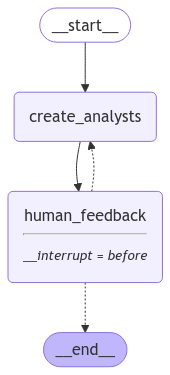

In [30]:
temp_interview = StateGraph(ParentState)
temp_interview.add_node("create_analysts", create_analysts) 
temp_interview.add_node("human_feedback", human_feedback)

temp_interview.add_edge(START, "create_analysts")
temp_interview.add_edge("create_analysts", "human_feedback")
temp_interview.add_conditional_edges("human_feedback", should_continue, ["create_analysts", END])

# Compile
memory = MemorySaver()
# NOTE: checkpointer here?
temp_graph = temp_interview.compile(interrupt_before=['human_feedback'])

# View
display(Image(temp_graph.get_graph(xray=1).draw_mermaid_png()))

##### Conduct Interview Subgraph

In [31]:
# Q/A instructions

QUESTION_INSTRUCTIONS = """You are an analyst tasked with interviewing a candidate to learn about a specific aspect of their expertise, experience, or perspective.

Your goal is boil down to interesting and specific insights related to your candidate and their accomplishments.

1. Interesting: Gather information that reveals deeper aspects of the candidate's experience, thought process, and decision-making abilities.
        
2. Specific: Ask questions that go beyond generalities and elicit concrete examples and scenarios from the candidate's past experiences.

Here is your topic of focus and set of goals: {goals}

Here is the candidate's resume: 
{annotated_resume}
        
Begin by introducing yourself using a name that fits your persona, and then ask your question.

Continue to ask questions to drill down and refine your understanding of the candidate.
        
When you are satisfied with your understanding, complete the interview with: "Thank you so much for your help!"

Remember to stay in character throughout your response, reflecting the persona and goals provided to you."""


ANSWER_INSTRUCTIONS = """You are a candidate being interviewed by an analyst.

Here is analyst area of focus: {goals}. 
        
You goal is to answer a question posed by the interviewer using a maximum of four sentences.

To answer the question, use your AnnotatedResume which contains high-level information about your professional and academic career (like a resume) and your Documents which contain fine-grain information.

Here is your AnnotatedResume:
{annotated_resume}

Here are your Documents (may be empty):
{documents}

When answering questions, follow these guidelines:
        
1. Use only the information provided in the AnnotatedResume and Documents. 
        
2. Do not introduce external information or make assumptions beyond what is explicitly stated in the Profile and Documents.

3. The Documents contain sources at the topic of each individual document.

4. Include these sources your answer next to any relevant statements. For example, for source # 1 use [1]. 

5. List your sources in order at the bottom of your answer. [1] Source 1, [2] Source 2, etc
        
And skip the addition of the brackets as well as the Document source preamble in your citation.
"""


In [32]:
from langchain_core.messages import get_buffer_string
from langchain_core.messages import AIMessage, HumanMessage, SystemMessage

In [33]:
# Intervies State and Search Query
class InterviewState(MessagesState):
    # active_application: Application
    final_report: str
    sections: Annotated[list, operator.add] # Final key we duplicate in outer state for Send() API
    max_num_turns: int # Number turns of conversation
    analyst: Analyst # Analyst asking questions
    interview: str # Interview transcript

In [34]:
# generate questions
def generate_question(state: InterviewState, config: RunnableConfig, store: BaseStore):
    """ Node to generate a question """

    user_id = config["configurable"]["user_id"]

    namespace = ("annotated_resume", user_id)
    memories = store.search(namespace)
    if memories:
        annotated_resume = memories[0].value
    else:
        annotated_resume = None
    
    # Get state
    analyst = state["analyst"]
    messages = state["messages"]

    # Generate question 
    
    system_message = QUESTION_INSTRUCTIONS.format(
        annotated_resume=annotated_resume,
        goals=analyst.persona,
    )
    question = model.invoke([SystemMessage(content=system_message)]+messages)
    question.name = "expert"
    
    # Write messages to state
    return {"messages": [question]}

In [35]:
# generate answer
def generate_answer(state: InterviewState, config: RunnableConfig, store: BaseStore):
    
    """ Node to answer a question """

    # Get state
    # analyst = state["analyst"]
    analyst = state["analyst"]
    messages = state["messages"]
    # context = state["context"]

    user_id = config["configurable"]["user_id"]

    namespace = ("annotated_resume", user_id)
    memories = store.search(namespace)
    if memories:
        annotated_resume = memories[0].value
    else:
        annotated_resume = None

    namespace = ("documents", user_id)
    memories = store.search(namespace)
    if memories:
        documents = memories[0].value
    else:
        documents = None

        
    # Answer question
    system_message = ANSWER_INSTRUCTIONS.format(
        goals=analyst.persona,
        annotated_resume=annotated_resume,
        documents=documents
    )
    answer = model.invoke([SystemMessage(content=system_message)]+messages)
            
    # Name the message as coming from the candidate
    answer.name = "candidate"
    
    # Append it to state
    return {"messages": [answer]}

In [36]:
# save interview
def save_interview(state: InterviewState):
    
    """ Save interviews """

    # Get messages
    messages = state["messages"]
    
    # Convert interview to a string
    interview = get_buffer_string(messages)
    
    # Save to interviews key
    return {"interview": interview}

In [37]:
# conditional edge
def route_messages(state: InterviewState, 
                   name: str = "expert"):

    """ Route between question and answer """
    
    # Get messages
    messages = state["messages"]
    max_num_turns = state.get('max_num_turns', 2)

    # Check the number of expert answers 
    num_responses = len(
        [m for m in messages if isinstance(m, AIMessage) and m.name == name]
    )

    # End if expert has answered more than the max turns
    if num_responses >= max_num_turns:
        return 'save_interview'

    # This router is run after each question - answer pair 
    # Get the last question asked to check if it signals the end of discussion
    last_question = messages[-2]
    
    if "Thank you so much for your help" in last_question.content:
        return 'save_interview'
    return "ask_question"

In [38]:
# WEAKNESSES_INSTRUCTIONS = """critiquing the candidate's shortcomings and specific areas for improvement relating to the candidate's specific skills, experiences, or accomplishments."""

# STRENGTHS_INSTRUCTIONS = """the candidate's strengths and accomplishments relating to the candidate's specific skills, experiences, or accomplishments, and the job requirements."""

# EVALUATION_INSTRUCTIONS = """holistically evaluating the candidate's ability to meet the requirements for the job. Rate the candidate's overall fit for the job based on the interview on a scale of 0 through 100."""


In [39]:
SECTION_WRITER_INSTRUCTIONS = """You are an expert technical writer. 

Your task is to create a short, easily digestible section of a report based on an interview transcript.
This report should focus on the three following components:

1. Weaknesses: critique the candidate's shortcomings and specific areas for improvement relating to the candidate's specific skills, experiences, or accomplishments.

2. Strengths: highlight the candidate's strengths and accomplishments relating to the candidate's specific skills, experiences, or accomplishments, and the job requirements.

3. Evaluation: holistically evaluate the candidate's ability to meet the requirements for the job. Rate the candidate's overall fit for the job based on the interview on a scale of 0 to 100.

Follow these instructions carefully:

1. Each point you make should be followed by a reference to the specific item in the candidate's resume or documents that it directly relates to.
"""


# SECTION_WRITER_INSTRUCTIONS = """You are an expert technical writer. 

# Your task is to create a short, easily digestible section of a report based on an interview transcript.
# This report should focus on {focus}

# Follow these instructions carefully:

# 1. Each point you make should be followed by a reference to the specific item in the candidate's resume or documents that it directly relates to.

# """

In [40]:
FINALIZE_INTERVIEW_INSTRUCTIONS = """You are tasked with writing a final report based on memos analysts have taken down from interviewing a candidate. Follow the same structure as each analysts with strengths, weaknesses, and evaluation sections.

Here are the memos from each analyst:
{sections}
"""

In [41]:
# write section

# FOCUS_INSTRUCTIONS = {
#     "weaknesses": WEAKNESSES_INSTRUCTIONS,
#     "strengths": STRENGTHS_INSTRUCTIONS,
#     "evaluation": EVALUATION_INSTRUCTIONS
# }

def write_section(state: InterviewState):
    """ Node to answer a question """

    # Get state
    interview = state["interview"]
    analyst = state["analyst"]
    # focus_instructions = FOCUS_INSTRUCTIONS[focus]
    # Write section using either the gathered source docs from interview (context) or the interview itself (interview)
    system_message = SECTION_WRITER_INSTRUCTIONS.format()
    section = model.invoke([SystemMessage(content=system_message)]+[HumanMessage(content=f"Here's the interview transpcript:\n{interview}")]) 
                
    # Append it to state
    print(section.content)
    return {"sections": [section.content]} 

In [42]:
def finalize_interview(state: ParentState):
    """ The is the "reduce" step where we gather all the sections, combine them, and reflect on them to write the final interview report. """
    # Save full final report

    sections = state["sections"]
    formatted_str_sections = "\n\n".join([f"{section}" for section in sections])
    
    # Summarize the sections into a final report
    
    instructions = FINALIZE_INTERVIEW_INSTRUCTIONS.format(sections=formatted_str_sections)
    final_report = model.invoke([instructions]+[HumanMessage(content=f"Write the report conclusion")]) 
    return {"final_report": final_report}

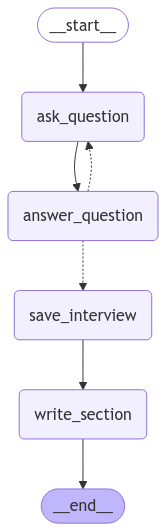

In [43]:
# Add nodes and edges 
interview_builder = StateGraph(InterviewState)
interview_builder.add_node("ask_question", generate_question)
interview_builder.add_node("answer_question", generate_answer)
interview_builder.add_node(save_interview)
interview_builder.add_node(write_section)
# interview_builder.add_node(write_weaknesses)
# interview_builder.add_node(write_strengths)
# interview_builder.add_node(write_evaluation)
# interview_builder.add_node(finalize_interview)

# Flow
interview_builder.add_edge(START, "ask_question")
interview_builder.add_edge("ask_question", "answer_question")
interview_builder.add_conditional_edges("answer_question", route_messages,['ask_question','save_interview'])
interview_builder.add_edge("save_interview", "write_section")
interview_builder.add_edge("write_section", END)
# interview_builder.add_edge("save_interview", "write_weaknesses")
# interview_builder.add_edge("save_interview", "write_strengths")
# interview_builder.add_edge("save_interview", "write_evaluation")
# interview_builder.add_edge("write_weaknesses", "finalize_interview")
# interview_builder.add_edge("write_strengths", "finalize_interview")
# interview_builder.add_edge("write_evaluation", "finalize_interview")
# interview_builder.add_edge("finalize_interview", END)

# Interview 
across_thread_memory = InMemoryStore()
memory = MemorySaver()
interview_graph = interview_builder.compile(
  checkpointer=memory,
  store=across_thread_memory
).with_config(run_name="Conduct Interviews")

# View
display(Image(interview_graph.get_graph().draw_mermaid_png()))

##### Main Graph

In [44]:
from langgraph.constants import Send

def initiate_all_interviews(state: ParentState):
    """ This is the "map" step where we run each interview sub-graph using Send API """    

    # Check if human feedback
    human_analyst_feedback=state.get('human_analyst_feedback')
    if human_analyst_feedback:
        # Return to create_analysts
        return "create_analysts"

    # Otherwise kick off interviews in parallel via Send() API
    else:
        # topic = state["topic"]
        return [Send("conduct_interview", {"analyst": analyst,
                                           "messages": [HumanMessage(
                                               content=f"Let's begin the interview."
                                           )
                                                       ]}) for analyst in state["analysts"]]

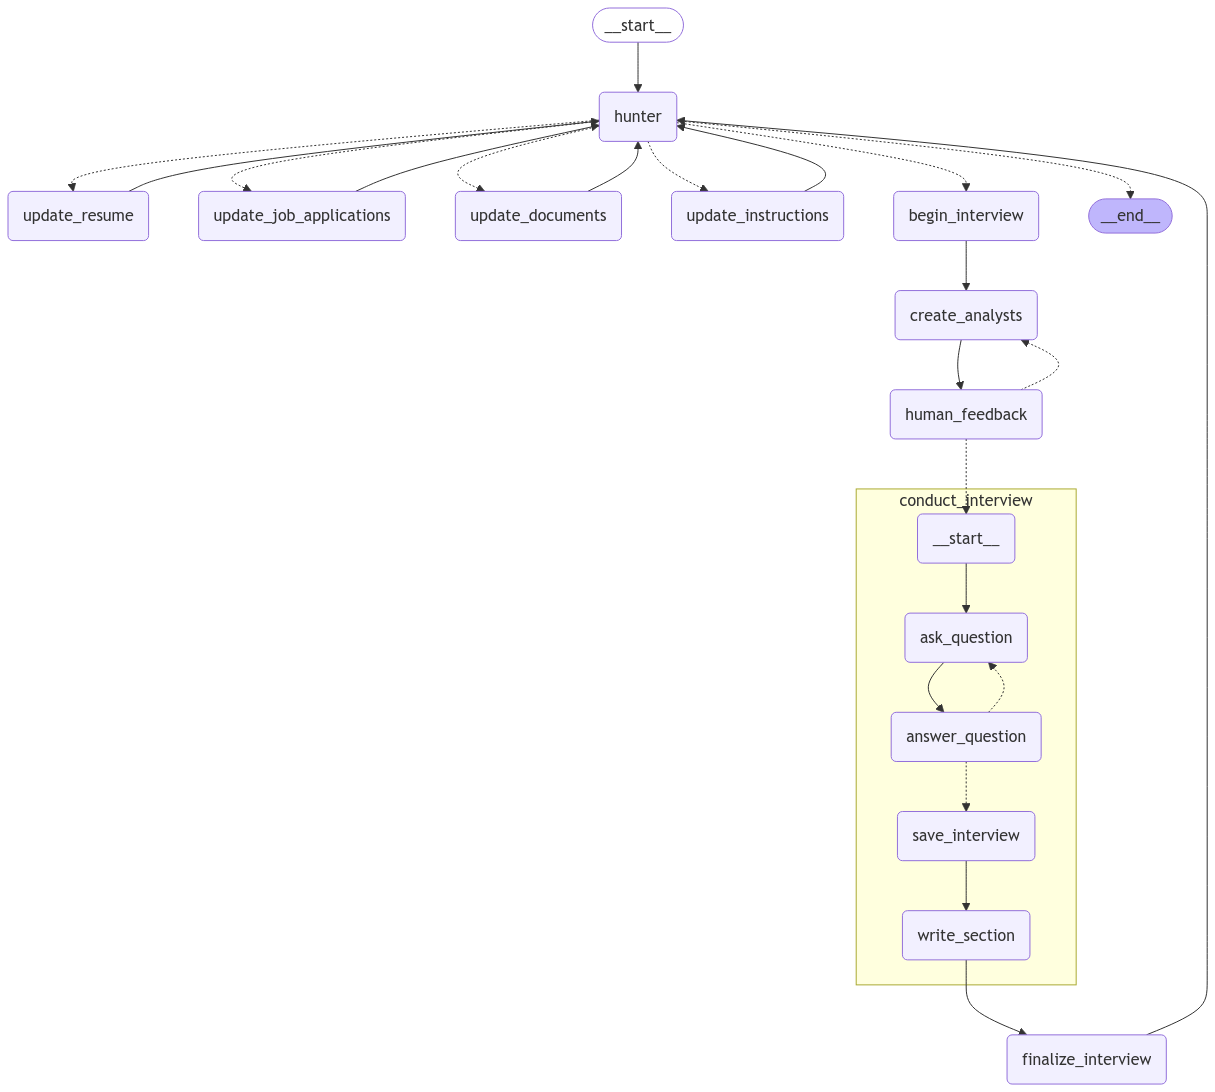

In [45]:
# Create the graph + all nodes
builder = StateGraph(ParentState)

# Define the flow of the memory extraction process
builder.add_node(hunter)
builder.add_node(update_resume)
builder.add_node(update_job_applications)
builder.add_node(update_documents)
builder.add_node(update_instructions)
builder.add_node(begin_interview)
builder.add_node(create_analysts) 
builder.add_node(human_feedback)
builder.add_node("conduct_interview", interview_builder.compile())
builder.add_node(finalize_interview)

builder.add_edge(START, "hunter")
builder.add_conditional_edges("hunter", route_message)
builder.add_edge("update_resume", "hunter")
builder.add_edge("update_job_applications", "hunter")
builder.add_edge("update_documents", "hunter")
builder.add_edge("update_instructions", "hunter")
builder.add_edge("begin_interview", "create_analysts")
builder.add_edge("create_analysts", "human_feedback")
# builder.add_conditional_edges("human_feedback", should_continue, ["create_analysts", "conduct_interview"])
builder.add_conditional_edges("human_feedback", initiate_all_interviews, ["create_analysts", "conduct_interview"])
builder.add_edge("conduct_interview", "finalize_interview")
builder.add_edge("finalize_interview", "hunter")


# builder.add_edge("conduct_interview", "hunter")

# Store for long-term (across-thread) memory
across_thread_memory = InMemoryStore()

# Checkpointer for short-term (within-thread) memory
within_thread_memory = MemorySaver()

# We compile the graph with the checkpointer and store
graph = builder.compile(checkpointer=within_thread_memory, store=across_thread_memory)

# View
display(Image(graph.get_graph(xray=1).draw_mermaid_png()))

##### Testing 

In [46]:
# sample resume
SAMPLE_RESUME = """
Hance Stevenson
Cameron Communication
Baltimore, MD
123-456-7891, lance@umd.edu

EDUCATION
University of Maryland, College Park — May 2023

Bachelor of Arts in Communication (Public Relations Track)
Baltimore High School, Baltimore, MD — June 2019

Sonya Koveleski Award (May 2019), an award given to the top math student in the senior class
GPA: 3.75

RELEVANT PROJECTS
Carillon Communities, University of Maryland, College Park — September 2023 - Present
“Design My Maryland” Plan

Create “Fearless Mission Statement” through an iterative design process to gain vision for “Design My Maryland” Plan
Utilize online portfolio system to showcase communication and leadership skills developed through creation of “Design My Maryland” Plan
COMM200: Critical Thinking and Speaking, University of Maryland, College Park — September 2023 - Present
Fearless Leadership Presentation


LEADERSHIP EXPERIENCE
Terp & Eagle Science Club, University of Maryland, College Park — September 2023 - Present
Tutor

Assist 2-5 elementary students with science homework during weekly hour-long study sessions
Coordinate with teachers to help provide additional lessons to struggling students
Learn valuable skills in planning, organizing, and management in elementary education
Women's Varsity Lacrosse, Baltimore High School — January 2018 - May 2019
Senior Captain

SKILLS
Technology: Microsoft Word & PowerPoint, Google Drive
Social Media: Instagram, Facebook, Twitter, Hootsuite"""

In [48]:
# sample job posting
JOB_POSTING = """
Distinguished Machine Learning Engineer

As a Capital One Machine Learning Engineer, you'll be providing technical leadership to engineering teams dedicated to productionizing machine learning applications and systems at scale. You'll participate in the detailed technical design, development, and implementation of machine learning applications using existing and emerging technology platforms. You'll serve as a technical domain expert in machine learning, guiding machine learning architectural design decisions, developing and reviewing model and application code, and ensuring high availability and performance of our machine learning applications. You'll have the opportunity to continuously learn and apply the latest innovations and best practices in machine learning engineering. You'll also mentor other engineers and further develop your technical knowledge and skills to keep Capital One at the cutting edge of technology.

In this role, you will be supporting the Bank Tech organization. You will lead development and implementation that will enable business initiatives, working with other leaders and teams across the enterprise to enable these solutions. .

What you'll do in the role:

Deliver ML models and software components that solve challenging business problems in the financial services industry, working in collaboration with the Product, Architecture, Engineering, and Data Science teams.

Drive the creation and evolution of ML models and software that enable state-of-the-art intelligent systems.

Lead large-scale ML initiatives with the customer in mind.

Leverage cloud-based architectures and technologies to deliver optimized ML models at scale.

Optimize data pipelines to feed ML models.

Use programming languages like Python, Scala, C/C++.

Leverage compute technologies such as Dask and RAPIDS

Evangelize best practices in all aspects of the engineering and modeling lifecycles.

Help recruit, nurture, and retain top engineering talent.

Basic Qualifications

Bachelor's degree.

At least 10 years of experience designing and building data-intensive solutions using distributed computing.

At least 6 years of experience programming in C, C++, Python, or Scala.

At least 3 years of experience with the full ML development lifecycle using modern technology in a business critical setting.

At least 2 years of experience using Dask, RAPIDS, or in High Performance Computing

At least 2 years of experience with the PyData ecosystem (NumPy, Pandas, and Scikit-learn)

Preferred Qualifications

Master's or doctoral degree in computer science, electrical engineering, mathematics, or a similar field.

3+ years of experience designing, implementing, and scaling  production-ready data pipelines that feed ML models.

8+ years of experience within a large/data-intensive multi-line business environment.

Experience partnering with technology peers responsible for data architecture and distributed computing infrastructure/platforms.

Ability to communicate complex technical concepts clearly to a variety of audiences.

ML industry impact through conference presentations, papers, blog posts, or open source contributions.

Ability to attract and develop high-performing software engineers with an inspiring leadership style.

 

At this time, Capital One will sponsor a new applicant for employment authorization for this position.

The minimum and maximum full-time annual salaries for this role are listed below, by location. Please note that this salary information is solely for candidates hired to perform work within one of these locations, and refers to the amount Capital One is willing to pay at the time of this posting. Salaries for part-time roles will be prorated based upon the agreed upon number of hours to be regularly worked.

Richmond, VA: $239,900 - $273,800 for Distinguished Machine Learning Engineer

 

New York, NY: $287,800 - $328,500 for Distinguished Machine Learning Engineer

 

McLean, VA: $263,900 - $301,200 for Distinguished Machine Learning Engineer

 

Philadelphia, PA: $239,900 - $273,800 for Distinguished Machine Learning Engineer

 

Wilmington, DE: $239,900 - $273,800 for Distinguished Machine Learning Engineer


Candidates hired to work in other locations will be subject to the pay range associated with that location, and the actual annualized salary amount offered to any candidate at the time of hire will be reflected solely in the candidate's offer letter.

This role is also eligible to earn performance based incentive compensation, which may include cash bonus(es) and/or long term incentives (LTI). Incentives could be discretionary or non discretionary depending on the plan.
Capital One offers a comprehensive, competitive, and inclusive set of health, financial and other benefits that support your total well-being. Learn more at the Capital One Careers website. Eligibility varies based on full or part-time status, exempt or non-exempt status, and management level.

For technical support or questions about Capital One's recruiting process, please send an email to Careers@capitalone.com"""

In [49]:
# config and utils
config = {"configurable": {"thread_id": "1", "user_id": "Hance"}}
user_id = 'Hance'

def run_graph(input_messages):
  input_messages = [HumanMessage(content=input_messages)]
  for chunk in graph.stream({"messages": input_messages}, config, stream_mode="values"):
    # print(chunk)
    # print('------')
    chunk["messages"][-1].pretty_print()

def view_ltm(memory):
  for memory in across_thread_memory.search((memory, user_id)):
    for key, value in memory.value.items():
        print(f"{key}:\n{value}\n")

Profile

In [50]:
# User input to create a profile memory
run_graph(f'Hi, the following is my resume.\n {SAMPLE_RESUME}')

================================ Human Message =================================

Hi, the following is my resume.
 
Hance Stevenson
Cameron Communication
Baltimore, MD
123-456-7891, lance@umd.edu

EDUCATION
University of Maryland, College Park — May 2023

Bachelor of Arts in Communication (Public Relations Track)
Baltimore High School, Baltimore, MD — June 2019

Sonya Koveleski Award (May 2019), an award given to the top math student in the senior class
GPA: 3.75

RELEVANT PROJECTS
Carillon Communities, University of Maryland, College Park — September 2023 - Present
“Design My Maryland” Plan

Create “Fearless Mission Statement” through an iterative design process to gain vision for “Design My Maryland” Plan
Utilize online portfolio system to showcase communication and leadership skills developed through creation of “Design My Maryland” Plan
COMM200: Critical Thinking and Speaking, University of Maryland, College Park — September 2023 - Present
Fearless Leadership Presentation


LEADERS

In [50]:
run_graph("What's in the contact_info section of my resume?")

================================ Human Message =================================

What's in the contact_info section of my resume?
================================== Ai Message ==================================

The contact information in your resume is as follows:

```
Hance Stevenson
Cameron Communication
Baltimore, MD
123-456-7891, lance@umd.edu
```

If you need any changes or additions, just let me know!


In [51]:
run_graph("I am looking to transition into a product management role.")

================================ Human Message =================================

I am looking to transition into a product management role.
================================== Ai Message ==================================

That's great! Transitioning into a product management role can be an exciting opportunity. To help you with this transition, we can focus on highlighting relevant skills and experiences in your resume, such as leadership, communication, and any project management experience you might have. 

If you have any specific experiences or skills related to product management that you'd like to add to your resume, feel free to share them with me. Additionally, if you have any preferences for how you'd like your resume to be updated to better align with product management roles, let me know!


In [52]:
run_graph("Let's update my objective to that.")

================================ Human Message =================================

Let's update my objective to that.
================================== Ai Message ==================================
Tool Calls:
  UpdateMemory (call_0kQL1Ik1WcLgxt8YNozGdBJO)
 Call ID: call_0kQL1Ik1WcLgxt8YNozGdBJO
  Args:
    update_type: annotated_resume
================================= Tool Message =================================

updated resume
================================== Ai Message ==================================

I've updated your resume objective to reflect your interest in transitioning into a product management role. If there's anything else you'd like to adjust or add, just let me know!


In [53]:
# Look at LTM
view_ltm('annotated_resume')

contact_info:
{'items': [{'content': 'Hance Stevenson\nCameron Communication\nBaltimore, MD\n123-456-7891, lance@umd.edu', 'interview_notes': None}], 'notes': None}

objective:
{'content': 'Aspiring product manager seeking to leverage communication and leadership skills to drive product development and innovation.', 'interview_notes': None}

education:
{'items': [{'content': 'University of Maryland, College Park — May 2023\n\nBachelor of Arts in Communication (Public Relations Track)', 'interview_notes': None}, {'content': 'Baltimore High School, Baltimore, MD — June 2019\n\nSonya Koveleski Award (May 2019), an award given to the top math student in the senior class\nGPA: 3.75', 'interview_notes': None}], 'notes': None}

technical_skills:
{'items': [], 'notes': None}

experience:
{'items': [{'content': 'Carillon Communities, University of Maryland, College Park — September 2023 - Present\n“Design My Maryland” Plan\n\nCreate “Fearless Mission Statement” through an iterative design proce

Job Applications

In [54]:
run_graph(f'Here a job application that I want to apply to.\n {JOB_POSTING}')

================================ Human Message =================================

Here a job application that I want to apply to.
 
Distinguished Machine Learning Engineer

As a Capital One Machine Learning Engineer, you'll be providing technical leadership to engineering teams dedicated to productionizing machine learning applications and systems at scale. You'll participate in the detailed technical design, development, and implementation of machine learning applications using existing and emerging technology platforms. You'll serve as a technical domain expert in machine learning, guiding machine learning architectural design decisions, developing and reviewing model and application code, and ensuring high availability and performance of our machine learning applications. You'll have the opportunity to continuously learn and apply the latest innovations and best practices in machine learning engineering. You'll also mentor other engineers and further develop your technical knowledge

In [55]:
# run_graph("what jobs do I currently have applications for?")

In [56]:
# run_graph("What's the deadline for this?")
# run_graph("The application deadline is actually January 25, 2025.")

In [57]:
# view_ltm("applications")

In [58]:
# run_graph("let's remove this job application")

In [59]:
# run_graph('actually, add it back.')

In [60]:
# view_ltm('applications')

In [61]:
run_graph("Let's begin the interview for this job application.")

================================ Human Message =================================

Let's begin the interview for this job application.


================================== Ai Message ==================================
Tool Calls:
  UpdateMemory (call_A6oUqt9D59jflpInZUVVunDV)
 Call ID: call_A6oUqt9D59jflpInZUVVunDV
  Args:
    update_type: active_application
================================= Tool Message =================================

updated active application
Active application: {'posting': {'job_title': 'Distinguished Machine Learning Engineer', 'company': {'name': 'Capital One', 'location': None, 'industry': None}, 'employment_type': None, 'job_description': "As a Capital One Machine Learning Engineer, you'll be providing technical leadership to engineering teams dedicated to productionizing machine learning applications and systems at scale. You'll participate in the detailed technical design, development, and implementation of machine learning applications using existing and emerging technology platforms. You'll serve as a technical domain expert in machine learning, guiding machine learning architectural desi

In [62]:
# Check
for event in graph.stream(None, config, stream_mode="values"):
    analysts = event.get('analysts', '')
    if analysts:
        for analyst in analysts:
            print(f"Name: {analyst.name}")
            # print(f"Affiliation: {analyst.affiliation}")
            print(f"Role: {analyst.role}")
            print(f"Description: {analyst.description}")
            print("-" * 50)  

Name: Dr. Emily Chen
Role: Machine Learning Architect
Description: Dr. Chen is focused on the architectural design and implementation of machine learning systems. She is particularly interested in how candidates approach the design of scalable and high-performance ML applications, especially in the context of financial services. Her concerns include ensuring the robustness and efficiency of ML models and their integration with existing technology platforms. She is also keen on understanding how candidates stay updated with the latest ML innovations and best practices.
--------------------------------------------------
Name: Michael Thompson
Role: Data Engineering Specialist
Description: Michael is an expert in data-intensive solutions and distributed computing. His focus is on the candidate's experience with optimizing data pipelines and leveraging cloud-based architectures to support ML models. He is interested in the candidate's proficiency with the PyData ecosystem and high-performa

In [ ]:
graph.update_state(config, {"human_analyst_feedback": 
                                "Add in the CEO of gen ai native startup"}, as_node="human_feedback")

{'configurable': {'thread_id': '1',
  'checkpoint_ns': '',
  'checkpoint_id': '1efdb725-5de7-69ef-801f-39fa121b5a93'}}

In [64]:
further_feedack = None
graph.update_state(config, {"human_analyst_feedback": 
                            further_feedack}, as_node="human_feedback")

{'configurable': {'thread_id': '1',
  'checkpoint_ns': '',
  'checkpoint_id': '1efdb725-5e15-6617-8020-e70bb3c551d3'}}

In [65]:
for event in graph.stream(None, config, stream_mode="updates"):
    print("--Node--")
    node_name = next(iter(event.keys()))
    print(node_name)

**Weaknesses:**

Michael Thompson's primary weakness lies in his lack of direct experience with data-intensive solutions and distributed computing, particularly in optimizing data pipelines or leveraging cloud-based architectures to support machine learning models. This gap in technical expertise is significant given the job's requirements for hands-on experience in these areas. His resume and interview responses indicate a focus on communication and leadership rather than technical execution in data-driven environments (Interview Transcript).

**Strengths:**

Michael's strengths are rooted in his communication and leadership capabilities. He has demonstrated the ability to develop and implement communication strategies effectively, as evidenced by his work on the "Design My Maryland" Plan. In this project, he successfully led the creation of a "Fearless Mission Statement" and utilized an online portfolio system to showcase his skills. His ability to facilitate collaboration and ensure

RateLimitError: Error code: 429 - {'error': {'message': 'Rate limit reached for gpt-4o in organization org-9QOLhtK2DqXqLsu1lJ1wVO6j on tokens per min (TPM): Limit 30000, Used 29845, Requested 1162. Please try again in 2.014s. Visit https://platform.openai.com/account/rate-limits to learn more.', 'type': 'tokens', 'param': None, 'code': 'rate_limit_exceeded'}}